# 03. Clinically Grounded Feature Engineering
**RoboDoctor AI — Phase 4: Biometric & Hemodynamic Biomarker Engineering**
*Author: Senior Machine Learning Engineer & Healthcare AI Engineer*

---

## 1. Objectives & Clinical Rationale
Rather than creating arbitrary polynomial combinations, healthcare AI models require features grounded in human cardiovascular physiology.
In this notebook, we investigate:
1. **Pulse Pressure ($PP = \text{sysBP} - \text{diaBP}$):** A direct clinical hallmark of central aortic stiffness and vascular remodeling.
2. **Mean Arterial Pressure ($MAP = \frac{\text{sysBP} + 2 \cdot \text{diaBP}}{3}$):** Measures average sustained organ perfusion pressure.
3. **Cumulative Tobacco Exposure ($\text{Age} \times \text{cigsPerDay}$):** A biological proxy for pack-year cumulative vascular endothelial injury.
4. **Metabolic Atherogenic Index ($\text{BMI} \times \text{glucose}$):** Captures the compounded risk of insulin resistance and visceral adiposity.
5. **Age Acceleration Factor ($(\text{Age} / 10)^2$):** Models non-linear cardiovascular mortality and arterial elasticity loss after age 45-50.
6. **Key Interaction Terms:**
   - $\text{Age} \times \text{SysBP}$: Compounding vascular tension with age.
   - $\text{Age} \times \text{Male}$: Sex-specific coronary incidence trajectory.
   - $\text{Age} \times \text{Diabetes}$: Microvascular acceleration with age.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.base import BaseEstimator, TransformerMixin

figures_dir = os.path.join('..', 'figures')
os.makedirs(figures_dir, exist_ok=True)

csv_path = os.path.join('..', 'data', 'framingham.csv')
df = pd.read_csv(csv_path)

# Correct inverted BP before computing hemodynamics
df['sysBP_corr'] = np.maximum(df['sysBP'], df['diaBP'])
df['diaBP_corr'] = np.minimum(df['sysBP'], df['diaBP'])


## 2. Deriving Physiological Features

In [2]:
# 1. Hemodynamics
df['pulsePressure'] = df['sysBP_corr'] - df['diaBP_corr']
df['meanArterialPressure'] = (df['sysBP_corr'] + 2 * df['diaBP_corr']) / 3.0

# 2. Cumulative smoking exposure
cigs = df['cigsPerDay'].fillna(0.0)
df['smokeCumulativeExposure'] = df['age'] * cigs

# 3. Metabolic index
glucose_imp = df['glucose'].fillna(df['glucose'].median())
bmi_imp = df['BMI'].fillna(df['BMI'].median())
df['metabolicIndex'] = bmi_imp * glucose_imp

# 4. Age non-linearity & interactions
df['ageSquared'] = (df['age'] / 10.0) ** 2
df['age_sysBP'] = (df['age'] * df['sysBP_corr']) / 100.0
df['age_male'] = df['age'] * df['male']
df['age_diabetes'] = df['age'] * df['diabetes']

derived_cols = [
    'pulsePressure', 'meanArterialPressure', 'smokeCumulativeExposure',
    'metabolicIndex', 'ageSquared', 'age_sysBP', 'age_male', 'age_diabetes'
]
df[derived_cols].describe().T[['mean', 'std', 'min', '50%', 'max']]


,mean,std,min,50%,max
pulsePressure,51.181038,24.342203,0.100,50.300000,139.600000
meanArterialPressure,98.546643,10.762048,52.300,98.633333,137.833333
smokeCumulativeExposure,371.644575,421.832221,0.000,0.000000,1980.000000
metabolicIndex,2148.922853,574.862687,585.302,2089.152500,7665.238000
ageSquared,26.597097,10.973060,10.240,25.000000,47.610000
age_sysBP,66.887144,18.071825,25.443,65.664000,141.381000
age_male,22.901415,26.231502,0.000,0.000000,69.000000
age_diabetes,1.183726,7.844891,0.000,0.000000,69.000000


## 3. Correlation with Target (`TenYearCHD`)

C:\Users\pratyaksh soni\AppData\Local\Temp\ipykernel_380\2174863641.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corrs.values, y=corrs.index, palette='coolwarm')


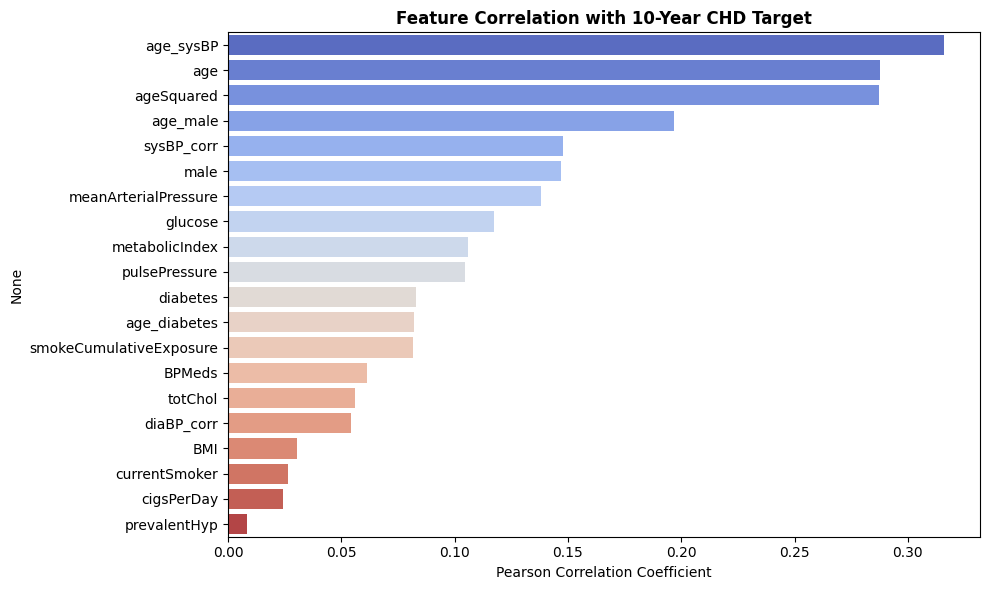

Top Correlations with 10-Year CHD:
age_sysBP               0.316049
age                     0.287908
ageSquared              0.287265
age_male                0.196722
sysBP_corr              0.147738
male                    0.146785
meanArterialPressure    0.138171
glucose                 0.117128
metabolicIndex          0.105937
pulsePressure           0.104566
dtype: float64


In [3]:
all_features = [
    'age', 'male', 'sysBP_corr', 'diaBP_corr', 'totChol', 'glucose', 'BMI',
    'currentSmoker', 'cigsPerDay', 'prevalentHyp', 'diabetes', 'BPMeds'
] + derived_cols

corrs = df[all_features].apply(lambda x: x.corr(df['TenYearCHD'])).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=corrs.values, y=corrs.index, palette='coolwarm')
plt.title('Feature Correlation with 10-Year CHD Target', fontsize=12, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, '02_feature_correlations.png'), dpi=300)
plt.show()

print("Top Correlations with 10-Year CHD:")
print(corrs.head(10))


## 4. Reusable Clinical Feature Engineering Transformer
We package the vetted features into a clean scikit-learn transformer `ClinicalFeatureEngineer`.


In [4]:
class ClinicalFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        
        # Ensure BP values are physiologically ordered
        sys_bp = np.maximum(X_df['sysBP'], X_df['diaBP'])
        dia_bp = np.minimum(X_df['sysBP'], X_df['diaBP'])
        
        # Derived Hemodynamics
        X_df['pulsePressure'] = sys_bp - dia_bp
        X_df['meanArterialPressure'] = (sys_bp + 2.0 * dia_bp) / 3.0
        
        # Cumulative Smoking Exposure
        cigs = X_df['cigsPerDay'].fillna(0.0)
        X_df['smokeCumulativeExposure'] = X_df['age'] * cigs
        
        # Metabolic Adiposity / Insulin Index
        glucose_val = X_df['glucose'].fillna(82.0)
        bmi_val = X_df['BMI'].fillna(25.7)
        X_df['metabolicIndex'] = bmi_val * glucose_val
        
        # Non-linear age & key interactions
        X_df['ageSquared'] = (X_df['age'] / 10.0) ** 2
        X_df['age_sysBP'] = (X_df['age'] * sys_bp) / 100.0
        X_df['age_male'] = X_df['age'] * X_df['male']
        X_df['age_diabetes'] = X_df['age'] * X_df['diabetes']
        
        return X_df

engineer = ClinicalFeatureEngineer()
engineered_sample = engineer.transform(df.drop(columns=['TenYearCHD', 'sysBP_corr', 'diaBP_corr']))
print(f"Original features: {df.shape[1] - 3}")
print(f"Engineered features total: {engineered_sample.shape[1]}")
print(f"New feature list: {list(engineered_sample.columns)}")


Original features: 23
Engineered features total: 23
New feature list: ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'pulsePressure', 'meanArterialPressure', 'smokeCumulativeExposure', 'metabolicIndex', 'ageSquared', 'age_sysBP', 'age_male', 'age_diabetes']


## 5. Summary of Phase 4 Decisions
- Retained 8 clinically validated biomarkers (Pulse Pressure, MAP, Smoke Exposure, Metabolic Index, Age Non-Linearity, Age-BP, Age-Sex, Age-Diabetes).
- Avoided high-degree polynomial proliferation.
- All derived features are deterministic and computable at prediction time from standard Vital Check inputs.
